# Tag EDA

Explore tags & their relationship with songs.

- How many songs per TAG 
- How many songs per TAG group 
- What are popular TAGs

In [1]:
# automatically reload imported modules before executing code

%load_ext autoreload
%autoreload 2

In [2]:
from nbutils import setup_path

setup_path()

In [3]:
from pyrekordbox import Rekordbox6Database
from pyrekordbox.db6 import tables


In [4]:
import polars as pl
from utils import get_clean_songs

db = Rekordbox6Database()

clean_songs_df = get_clean_songs(db)

clean_songs_df.head(5)

[08:44:49] pyrekordbox.db6.database:WARNING  - Rekordbox is running!


ContentID,FolderPath,Title,ArtistID,ArtistName,GenreID,GenreName,BPM,DateCreated,Length,MyTagNames,MyTagIDs,SampleRate,has_tags
str,str,str,str,str,str,str,i32,str,i32,list[str],list[str],i32,bool
"""36085625""","""/Users/quintenrosseel/Music/Pi…","""Surrender""","""1673664596""","""Gerd Janson""","""159652946""","""Techno/House""",12200,"""2021-12-26""",413,"[""AUTOTAG""]","[""2966753611""]",44100,false
"""18988943""","""/Users/quintenrosseel/Music/Pi…","""I Want Your Soul""","""1642798025""","""Armand Van Helden""","""3027895697""","""Classics/House""",12800,"""2021-12-26""",399,"[""AUTOTAG""]","[""2966753611""]",44100,false
"""118919255""","""/Users/quintenrosseel/Music/Pi…","""Save Our Love""","""2508199194""","""Escape From New York""","""3584637391""","""Disco""",11010,"""2022-08-23""",304,"[""80s"", ""Disco"", … ""Chill""]","[""1155275430"", ""62609778"", … ""3718426834""]",44100,true
"""228400738""","""/Users/quintenrosseel/Music/Pi…","""RENT4""","""3953188055""","""Lakim""","""4282047218""","""Garage""",14500,"""2021-07-17""",167,"[""AUTOTAG""]","[""2966753611""]",44100,false
"""217615930""","""/Users/quintenrosseel/Music/Pi…","""Funky Child (1993)""","""1137483595""","""Lords Of The Underground""","""2864790501""","""Hip-hop""",9630,"""2018-10-11""",227,"[""Beats"", ""Hip-Hop"", … ""TAG YEAR""]","[""2053683127"", ""3917148722"", … ""382831235""]",44100,true


In [6]:
import polars as pl
from utils import get_clean_tags


clean_tags_df = get_clean_tags(db)

clean_tags_df.head(5)

TagID,UUID,TagGroup,TagName
str,str,str,str
"""1429694612""","""3e973c3c-001b-4792-92f9-684d40…","""Genre""","""Techno"""
"""2484825285""","""22a59e2a-b3a6-470e-ad4b-92edda…","""Genre""","""Ambient"""
"""3917148722""","""7226a04c-8d3e-4f5a-b6be-acb6c5…","""Genre""","""Hip-Hop"""
"""323305339""","""e8484566-7872-449c-bbb6-e9002b…","""Genre""","""Motown"""
"""385085509""","""c9ab7b83-30a5-4797-b70c-7f18d7…","""Genre""","""Funk"""


# EDA
- Explode song per MyTagName to have a song-tag association
- Join this tag with their parent
- See the distributions 

In [7]:
from utils import get_clean_eda

clean_eda_df: pl.DataFrame = get_clean_eda(db)
clean_eda_df.head(n=5)

song_id,song_path,song_title,artist_id,artist_name,genre_id,genre_name,bpm,date_created,length,tag_id,sample_rate,has_tags,tag_uuid,tag_group,tag_name
str,str,str,str,str,str,str,i32,str,i32,str,i32,bool,str,str,str
"""36085625""","""/Users/quintenrosseel/Music/Pi…","""Surrender""","""1673664596""","""Gerd Janson""","""159652946""","""Techno/House""",12200,"""2021-12-26""",413,"""2966753611""",44100,false,"""3dfdbfcb-adec-456f-ad3e-86dace…","""Years & Origin""","""AUTOTAG"""
"""18988943""","""/Users/quintenrosseel/Music/Pi…","""I Want Your Soul""","""1642798025""","""Armand Van Helden""","""3027895697""","""Classics/House""",12800,"""2021-12-26""",399,"""2966753611""",44100,false,"""3dfdbfcb-adec-456f-ad3e-86dace…","""Years & Origin""","""AUTOTAG"""
"""118919255""","""/Users/quintenrosseel/Music/Pi…","""Save Our Love""","""2508199194""","""Escape From New York""","""3584637391""","""Disco""",11010,"""2022-08-23""",304,"""1155275430""",44100,true,"""e6444280-6cb5-4db9-a791-167f57…","""Years & Origin""","""80s"""
"""118919255""","""/Users/quintenrosseel/Music/Pi…","""Save Our Love""","""2508199194""","""Escape From New York""","""3584637391""","""Disco""",11010,"""2022-08-23""",304,"""62609778""",44100,true,"""9c39933a-bd9a-45e9-b710-e6cd2c…","""Genre""","""Disco"""
"""118919255""","""/Users/quintenrosseel/Music/Pi…","""Save Our Love""","""2508199194""","""Escape From New York""","""3584637391""","""Disco""",11010,"""2022-08-23""",304,"""385085509""",44100,true,"""c9ab7b83-30a5-4797-b70c-7f18d7…","""Genre""","""Funk"""


In [ ]:
# Write Out 
clean_eda_df.write_parquet("../data/base.parquet")

## Aggregations

Now let's compute key statistics about tags and their distributions.

In [8]:
# 1. Songs per TAG (most popular tags)
songs_per_tag = (
    clean_eda_df
    .filter(pl.col("tag_name").is_not_null())  # Only tagged songs
    .group_by("tag_name", "tag_group")
    .agg(
        pl.col("song_id").n_unique().alias("song_count")
    )
    .sort("song_count", descending=True)
)

print("Top 20 Tags by Song Count:")
print(songs_per_tag.head(20))

Top 20 Tags by Song Count:
shape: (20, 3)
┌────────────┬────────────────┬────────────┐
│ tag_name   ┆ tag_group      ┆ song_count │
│ ---        ┆ ---            ┆ ---        │
│ str        ┆ str            ┆ u32        │
╞════════════╪════════════════╪════════════╡
│ AUTOTAG    ┆ Years & Origin ┆ 1164       │
│ Good Vibes ┆ Mood           ┆ 388        │
│ Dancefloor ┆ Mood           ┆ 379        │
│ Soul       ┆ Genre          ┆ 364        │
│ Uplifting  ┆ Mood           ┆ 358        │
│ …          ┆ …              ┆ …          │
│ Chill      ┆ Mood           ┆ 193        │
│ Rave       ┆ Situation      ┆ 191        │
│ 2010s      ┆ Years & Origin ┆ 177        │
│ Classics   ┆ Situation      ┆ 170        │
│ Deep       ┆ Mood           ┆ 165        │
└────────────┴────────────────┴────────────┘


In [9]:
# 2. Songs per TAG GROUP
songs_per_tag_group = (
    clean_eda_df
    .filter(pl.col("tag_group").is_not_null())
    .group_by("tag_group")
    .agg(
        pl.col("song_id").n_unique().alias("song_count"),
        pl.col("tag_name").n_unique().alias("unique_tags")
    )
    .sort("song_count", descending=True)
)

print("\nSongs per Tag Group:")
print(songs_per_tag_group)


Songs per Tag Group:
shape: (4, 3)
┌────────────────┬────────────┬─────────────┐
│ tag_group      ┆ song_count ┆ unique_tags │
│ ---            ┆ ---        ┆ ---         │
│ str            ┆ u32        ┆ u32         │
╞════════════════╪════════════╪═════════════╡
│ Years & Origin ┆ 1804       ┆ 26          │
│ Genre          ┆ 698        ┆ 48          │
│ Situation      ┆ 696        ┆ 20          │
│ Mood           ┆ 686        ┆ 24          │
└────────────────┴────────────┴─────────────┘


In [10]:
# 3. Tags per SONG distribution
tags_per_song = (
    clean_songs_df
    .with_columns(
        pl.col("MyTagNames").list.len().alias("tag_count")
    )
    .group_by("tag_count")
    .agg(
        pl.count().alias("song_count")
    )
    .sort("tag_count")
)

print("\nTags per Song Distribution:")
print(tags_per_song)

# Summary stats
total_tagged_songs = clean_songs_df.filter(pl.col("has_tags")).shape[0]
total_songs = clean_songs_df.shape[0]
print(f"\nTotal songs: {total_songs}")
print(f"Songs with tags: {total_tagged_songs} ({total_tagged_songs/total_songs*100:.1f}%)")
print(f"Songs without tags: {total_songs - total_tagged_songs} ({(total_songs - total_tagged_songs)/total_songs*100:.1f}%)")


Tags per Song Distribution:
shape: (30, 2)
┌───────────┬────────────┐
│ tag_count ┆ song_count │
│ ---       ┆ ---        │
│ u32       ┆ u32        │
╞═══════════╪════════════╡
│ 1         ┆ 1164       │
│ 2         ┆ 8          │
│ 3         ┆ 6          │
│ 4         ┆ 10         │
│ 5         ┆ 10         │
│ …         ┆ …          │
│ 26        ┆ 4          │
│ 27        ┆ 2          │
│ 28        ┆ 1          │
│ 29        ┆ 1          │
│ 38        ┆ 1          │
└───────────┴────────────┘

Total songs: 1877
Songs with tags: 713 (38.0%)
Songs without tags: 1164 (62.0%)


/var/folders/2y/wcq7n_b14cqd36yz8rymh1540000gn/T/ipykernel_41980/1808267058.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("song_count")


In [11]:
# 4. Tag CO-OCCURRENCE: Which tags appear together?
# Create a matrix showing how often tags appear together on the same song

# First, get songs with multiple tags
multi_tag_songs = (
    clean_songs_df
    .filter(pl.col("MyTagNames").list.len() > 1)
    .select(["ContentID", "MyTagNames"])
)

# For each pair of tags that appear on the same song, count occurrences
from itertools import combinations

tag_pairs = []
for row in multi_tag_songs.iter_rows(named=True):
    tags = row["MyTagNames"]
    # Get all pairs of tags for this song
    for tag1, tag2 in combinations(sorted(tags), 2):
        tag_pairs.append({"tag1": tag1, "tag2": tag2})

if tag_pairs:
    tag_cooccurrence = (
        pl.DataFrame(tag_pairs)
        .group_by(["tag1", "tag2"])
        .agg(pl.count().alias("cooccurrence_count"))
        .sort("cooccurrence_count", descending=True)
    )
    
    print("\nTop 20 Tag Co-occurrences:")
    print(tag_cooccurrence.head(20))
else:
    print("\nNo tag co-occurrences found (no songs with multiple tags)")


Top 20 Tag Co-occurrences:
shape: (20, 3)
┌──────────────────────┬────────────┬────────────────────┐
│ tag1                 ┆ tag2       ┆ cooccurrence_count │
│ ---                  ┆ ---        ┆ ---                │
│ str                  ┆ str        ┆ u32                │
╞══════════════════════╪════════════╪════════════════════╡
│ Good Vibes           ┆ Soul       ┆ 299                │
│ Good Vibes           ┆ Uplifting  ┆ 292                │
│ Good Vibes           ┆ Sunset     ┆ 265                │
│ Dancefloor           ┆ Peak       ┆ 264                │
│ Soul                 ┆ Uplifting  ┆ 249                │
│ …                    ┆ …          ┆ …                  │
│ After Hours          ┆ Dancefloor ┆ 209                │
│ Build up             ┆ Dancefloor ┆ 206                │
│ Background           ┆ Loungy     ┆ 204                │
│ Dancefloor           ┆ House      ┆ 204                │
│ Live Instrument Gems ┆ Uplifting  ┆ 203                │
└────────────

/var/folders/2y/wcq7n_b14cqd36yz8rymh1540000gn/T/ipykernel_41980/2773419609.py:25: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("cooccurrence_count"))


In [23]:
tag_group_sets = (
    clean_songs_df
    .filter(pl.col("has_tags"))
    .with_columns(
        # For each song, extract tags that belong to each tag group
        pl.col("MyTagNames").list.eval(
            pl.element()
        ).alias("all_tags")
    )
    .explode("all_tags")
    .join(
        clean_tags_df.select(["TagName", "TagGroup"]),
        left_on="all_tags",
        right_on="TagName",
        how="left"
    )
    .group_by("ContentID", "TagGroup")
    .agg(
        pl.col("all_tags").sort().alias("tag_set")
    )
    .with_columns(
        pl.col("tag_set").list.join(", ").alias("tag_set_str")
    )
    .with_columns(
        pl.col("tag_set").list.len().alias("set_count")
    )
    .group_by("TagGroup", "tag_set_str", "set_count")
    .agg(
        pl.col("ContentID").n_unique().alias("song_count")
    )
    .sort(["TagGroup", "song_count"], descending=[False, True])
)

print("\nTag Set Combinations per Tag Group:")
print(tag_group_sets)

# Summary: how many unique sets per tag group
tag_group_set_summary = (
    tag_group_sets
    .group_by("TagGroup")
    .agg(
        pl.col("tag_set_str").n_unique().alias("unique_combinations"),
        pl.col("song_count").sum().alias("total_songs")
    )
    .sort("unique_combinations", descending=True)
)

print("\nSummary: Unique Tag Combinations per Tag Group:")
print(tag_group_set_summary)


Tag Set Combinations per Tag Group:
shape: (1_348, 4)
┌────────────────┬──────────────────────────┬───────────┬────────────┐
│ TagGroup       ┆ tag_set_str              ┆ set_count ┆ song_count │
│ ---            ┆ ---                      ┆ ---       ┆ ---        │
│ str            ┆ str                      ┆ u32       ┆ u32        │
╞════════════════╪══════════════════════════╪═══════════╪════════════╡
│ Genre          ┆ House, Soul              ┆ 2         ┆ 22         │
│ Genre          ┆ Disco, Funk, Soul        ┆ 3         ┆ 20         │
│ Genre          ┆ Disco, House, Soul       ┆ 3         ┆ 15         │
│ Genre          ┆ Disco, Funk, House, Soul ┆ 4         ┆ 15         │
│ Genre          ┆ House                    ┆ 1         ┆ 12         │
│ …              ┆ …                        ┆ …         ┆ …          │
│ Years & Origin ┆ 50s                      ┆ 1         ┆ 1          │
│ Years & Origin ┆ 2010s, 80s               ┆ 2         ┆ 1          │
│ Years & Origin ┆ 201

## Visualizations

Let's create some insightful visualizations using seaborn and plotly.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set seaborn style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

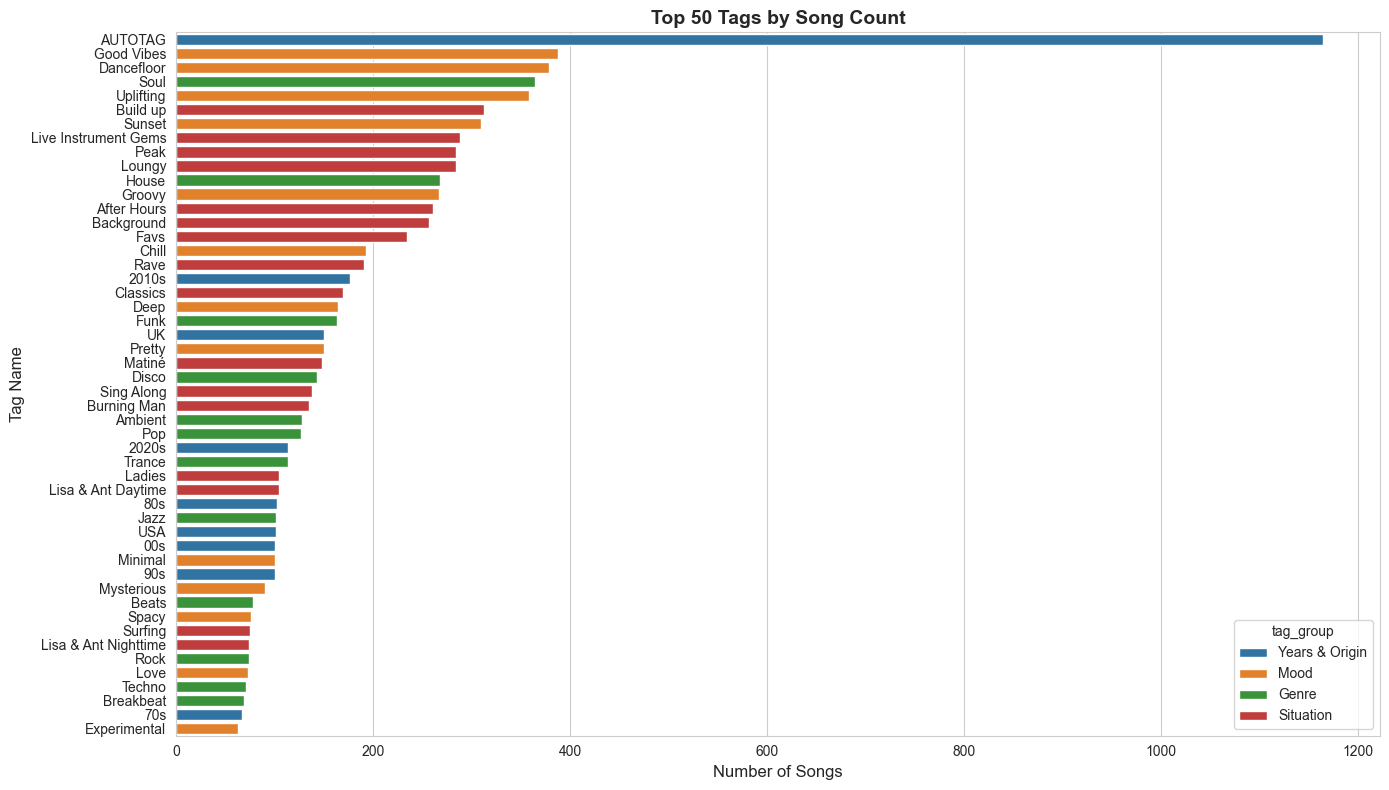

In [14]:
# 1. Bar Chart: Top 30 Tags by Song Count (Seaborn)
top_n = 50
top_tags = songs_per_tag.head(top_n)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top_tags,
    y="tag_name",
    x="song_count",
    hue="tag_group",
    ax=ax,
    dodge=False
)
ax.set_xlabel("Number of Songs", fontsize=12)
ax.set_ylabel("Tag Name", fontsize=12)
ax.set_title(f"Top {top_n} Tags by Song Count", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# 2. Bar Chart: Songs per Tag Group (Plotly - Interactive)
fig = px.bar(
    songs_per_tag_group,
    x="tag_group",
    y="song_count",
    color="unique_tags",
    title="Songs per Tag Group",
    labels={"song_count": "Number of Songs", "unique_tags": "Unique Tags"},
    text="song_count",
    color_continuous_scale="Viridis"
)
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(height=500)
fig.show()

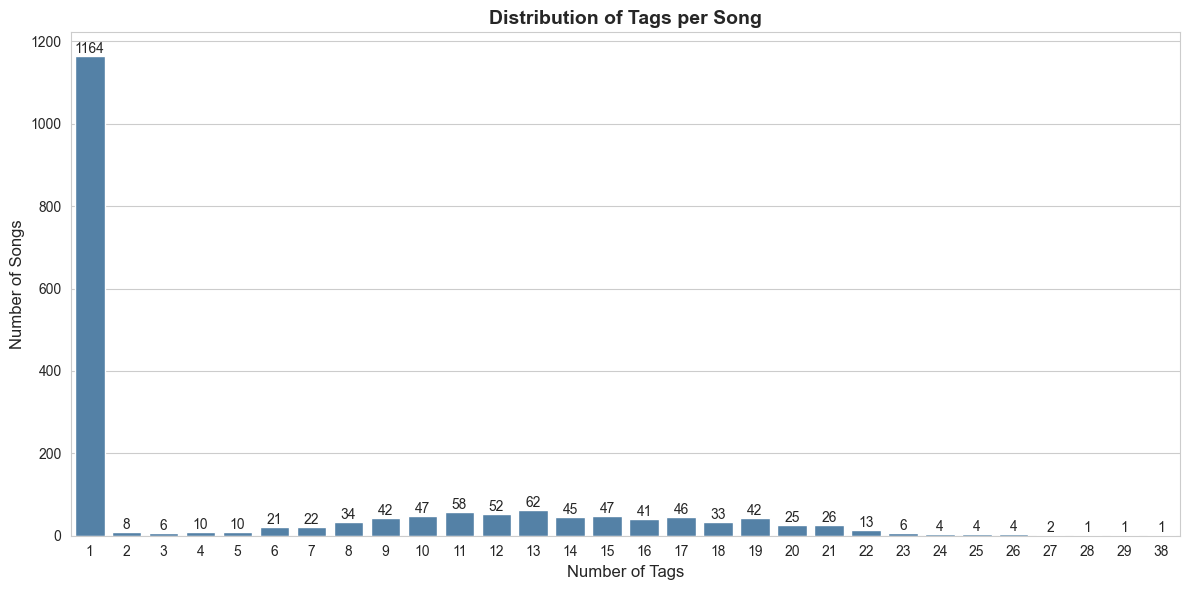

In [18]:
# 3. Histogram: Distribution of Tags per Song (Seaborn)
tags_per_song_df = tags_per_song.to_pandas()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=tags_per_song_df,
    x="tag_count",
    y="song_count",
    ax=ax,
    color="steelblue"
)
ax.set_xlabel("Number of Tags", fontsize=12)
ax.set_ylabel("Number of Songs", fontsize=12)
ax.set_title("Distribution of Tags per Song", fontsize=14, fontweight='bold')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [24]:
tag_group_sets

TagGroup,tag_set_str,set_count,song_count
str,str,u32,u32
"""Genre""","""House, Soul""",2,22
"""Genre""","""Disco, Funk, Soul""",3,20
"""Genre""","""Disco, House, Soul""",3,15
"""Genre""","""Disco, Funk, House, Soul""",4,15
"""Genre""","""House""",1,12
…,…,…,…
"""Years & Origin""","""50s""",1,1
"""Years & Origin""","""2010s, 80s""",2,1
"""Years & Origin""","""2010s, Arabic, German""",3,1


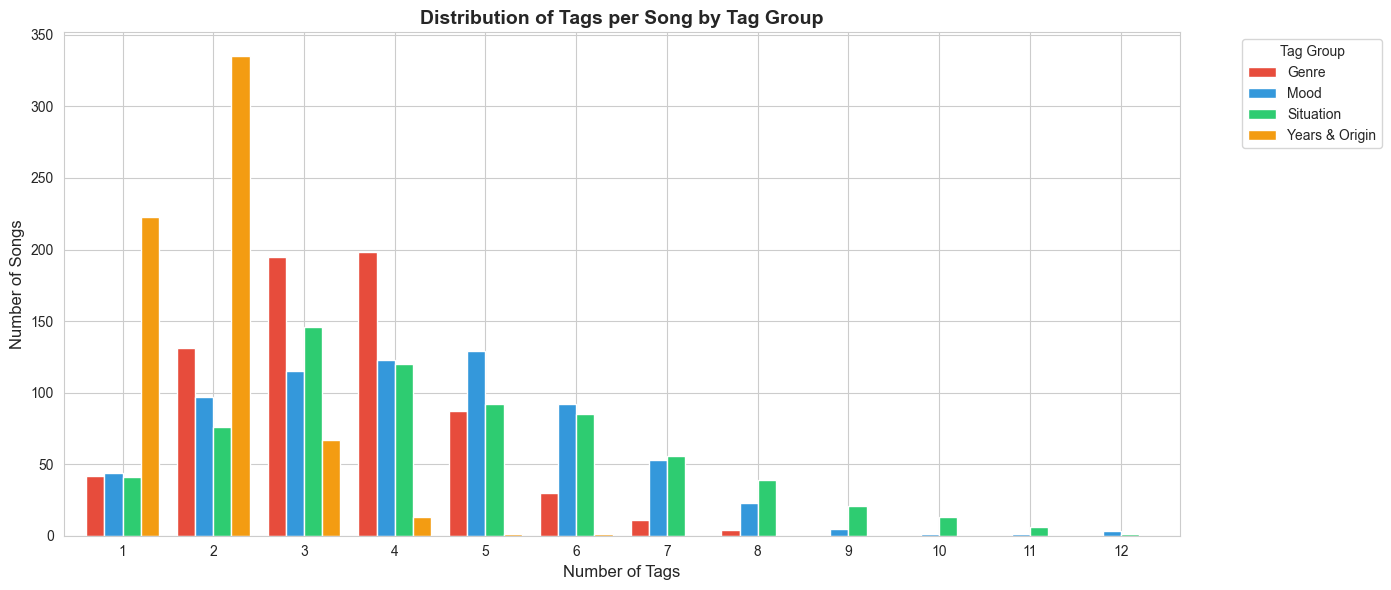

In [26]:
# Aggregate first to handle duplicates, then pivot
tag_group_sets_df = tag_group_sets.to_pandas()

# Group by set_count and TagGroup, summing song_counts
aggregated_df = tag_group_sets_df.groupby(['set_count', 'TagGroup'], as_index=False)['song_count'].sum()

pivot_df = aggregated_df.pivot(
    index="set_count",
    columns="TagGroup",
    values="song_count"
).fillna(0)

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(14, 6))

pivot_df.plot(
    kind='bar',
    ax=ax,
    color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'],  # red, blue, green, orange
    width=0.8
)

ax.set_xlabel("Number of Tags", fontsize=12)
ax.set_ylabel("Number of Songs", fontsize=12)
ax.set_title("Distribution of Tags per Song by Tag Group", fontsize=14, fontweight='bold')
ax.legend(title="Tag Group", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [27]:
# 4. Treemap: Hierarchical view of Tag Groups and Tags (Plotly)
# Prepare data for treemap: show tag groups and their top tags
top_tags_per_group = (
    songs_per_tag
    .sort("song_count", descending=True)
    .group_by("tag_group")
    .head(10)  # Top 10 tags per group
    .to_pandas()
)

fig = px.treemap(
    top_tags_per_group,
    path=["tag_group", "tag_name"],
    values="song_count",
    title="Tag Hierarchy: Groups and Popular Tags",
    color="song_count",
    color_continuous_scale="RdYlGn"
)
fig.update_layout(height=700)
fig.show()

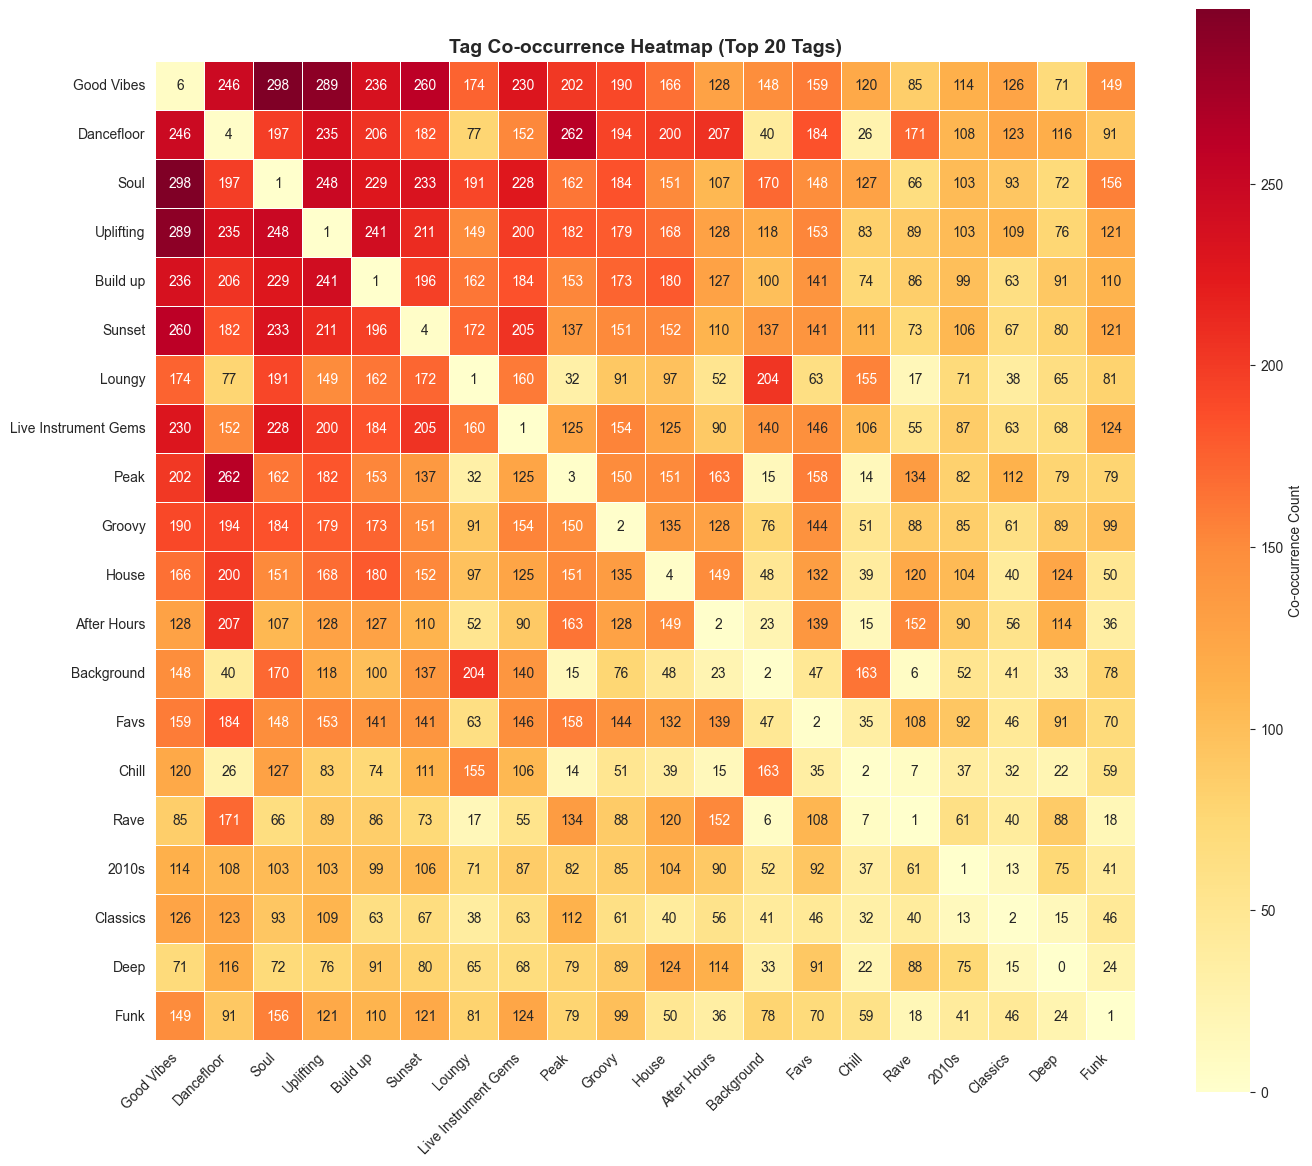

In [18]:
# 5. Heatmap: Tag Co-occurrence (Top 20 tags)
if tag_pairs:
    # Get top 20 most popular tags
    top_20_tags = songs_per_tag.head(20)["tag_name"].to_list()
    
    # Filter co-occurrence for top tags only
    top_cooccurrence = (
        tag_cooccurrence
        .filter(
            (pl.col("tag1").is_in(top_20_tags)) & 
            (pl.col("tag2").is_in(top_20_tags))
        )
    )
    
    # Create a symmetric matrix
    import pandas as pd
    import numpy as np
    
    cooccur_df = top_cooccurrence.to_pandas()
    matrix = pd.DataFrame(0, index=top_20_tags, columns=top_20_tags)
    
    for _, row in cooccur_df.iterrows():
        tag1, tag2, count = row["tag1"], row["tag2"], row["cooccurrence_count"]
        matrix.loc[tag1, tag2] = count
        matrix.loc[tag2, tag1] = count  # Symmetric
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        matrix,
        annot=True,
        fmt='g',
        cmap="YlOrRd",
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Co-occurrence Count"},
        ax=ax
    )
    ax.set_title("Tag Co-occurrence Heatmap (Top 20 Tags)", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No co-occurrence data available for heatmap")

In [28]:
# 6. Sunburst Chart: Interactive hierarchical view (Plotly)
# Shows tag groups and their constituent tags with proportional sizing

fig = px.sunburst(
    top_tags_per_group,
    path=["tag_group", "tag_name"],
    values="song_count",
    title="Tag Hierarchy Sunburst: Groups and Tags",
    color="song_count",
    color_continuous_scale="Blues"
)
fig.update_layout(height=700)
fig.show()

In [31]:
# 1. Stacked bar chart: Top tag combinations per group
top_combinations_per_group = (
    tag_group_sets
    .group_by("TagGroup")
    .head(10)  # Top 10 combinations per group
    .to_pandas()
)

fig = px.bar(
    top_combinations_per_group,
    x="song_count",
    y="tag_set_str",
    color="TagGroup",
    orientation="h",
    title="Top Tag Combinations per Tag Group",
    labels={"song_count": "Number of Songs", "tag_set_str": "Tag Combination"},
    height=800
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [29]:
# 2. Bar chart: Diversity of tag combinations per group
fig = px.bar(
    tag_group_set_summary.to_pandas(),
    x="TagGroup",
    y="unique_combinations",
    color="total_songs",
    title="Tag Combination Diversity by Tag Group",
    labels={"unique_combinations": "Unique Combinations", "total_songs": "Total Songs"},
    text="unique_combinations",
    color_continuous_scale="Viridis"
)
fig.update_traces(textposition='outside')
fig.show()

In [30]:
# 3. Sunburst: Tag group → combinations → songs
# Prepare data with hierarchy
sunburst_data = (
    tag_group_sets
    .group_by("TagGroup")
    .head(8)  # Top 8 per group to avoid clutter
    .to_pandas()
)

fig = px.sunburst(
    sunburst_data,
    path=["TagGroup", "tag_set_str"],
    values="song_count",
    title="Tag Combinations Hierarchy",
    color="song_count",
    color_continuous_scale="Turbo",
    height=800
)
fig.show()

In [37]:
pl.Config.set_tbl_rows(20)  # Show 100 rows

clean_eda_df[0, 'song_path']

'/Users/quintenrosseel/Music/PioneerDJ/Collection/Surrender.mp3'

## Additional Interesting Visualizations

Some other insights we could explore:
- **Genre Analysis**: BPM distribution per tag/genre
- **Temporal Analysis**: Tags by date created (trending tags over time)
- **Artist Analysis**: Most tagged artists, tags per artist
- **Network Graph**: Tag relationships as a network (requires networkx)
- **Radar Chart**: Tag group profiles for specific songs/playlists